In [ ]:
from google.colab import drive
import os

# Mounting Google Drive
drive.mount('/content/drive')

# Verify to see the folder
base_path = '/content/drive/MyDrive/MSc_Project/data'
if os.path.exists(base_path):
    print("SUCCESS: Connected to Google Drive!")
    print("Files found:", os.listdir(base_path))
else:
    print("ERROR: Could not find the folder. Check your folder names in Drive!")

Mounted at /content/drive
SUCCESS: Connected to Google Drive!
Files found: ['training_solutions_rev1.zip', 'images_training_rev1.zip', 'original_images']


In [ ]:
import zipfile
import os

# Defining  the paths to ZIP files
base_path = '/content/drive/MyDrive/MSc_Project/data'
zip_images = os.path.join(base_path, 'images_training_rev1.zip')
zip_labels = os.path.join(base_path, 'training_solutions_rev1.zip')

# Define where i want to put the unzipped files
# I unzip them to the local Colab environment (/content/) because it is MUCH faster than Drive
extract_path = '/content/unzipped_data'

print("Starting extraction...")

# 1. Unzip Images
if os.path.exists(zip_images):
    with zipfile.ZipFile(zip_images, 'r') as z:
        z.extractall(extract_path)
    print("Images extracted successfully!")
else:
    print("Error: Could not find images zip file.")

# 2. Unzip Labels (The CSV file)
if os.path.exists(zip_labels):
    with zipfile.ZipFile(zip_labels, 'r') as z:
        z.extractall(extract_path)
    print( "Labels extracted successfully!")
else:
    print(" Error: Could not find labels zip file.")

# Verify what i have
print(f"Extraction folder contents: {os.listdir(extract_path)}")

Starting extraction...
Images extracted successfully!
Labels extracted successfully!
Extraction folder contents: ['images_training_rev1', 'training_solutions_rev1.csv']


Total galaxy images found: 61578


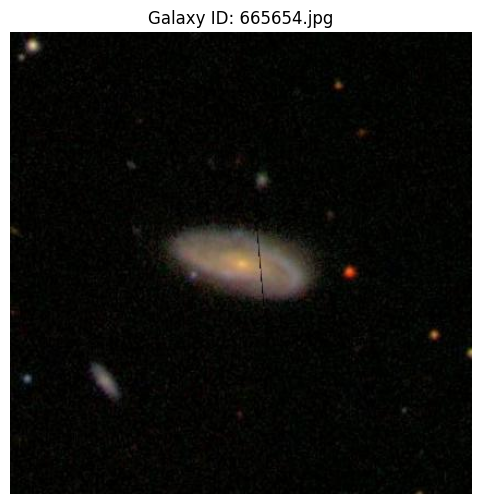

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# Define the folder where i just unzipped the images
image_folder = '/content/unzipped_data/images_training_rev1'

# Get a list of all image files
all_images = os.listdir(image_folder)
print(f"Total galaxy images found: {len(all_images)}")

# Pick a random image to display
random_image_file = random.choice(all_images)
image_path = os.path.join(image_folder, random_image_file)

# Load and show the image
img = mpimg.imread(image_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Galaxy ID: {random_image_file}")
plt.axis('off') # Turn off the X and Y axis numbers
plt.show()

Dataset Size: 61578 total images
----------------------------------------
Image Shape: (424, 424, 3) (Height, Width, Channels)
Data Type: uint8
Pixel Value Range: Min=0, Max=244
----------------------------------------


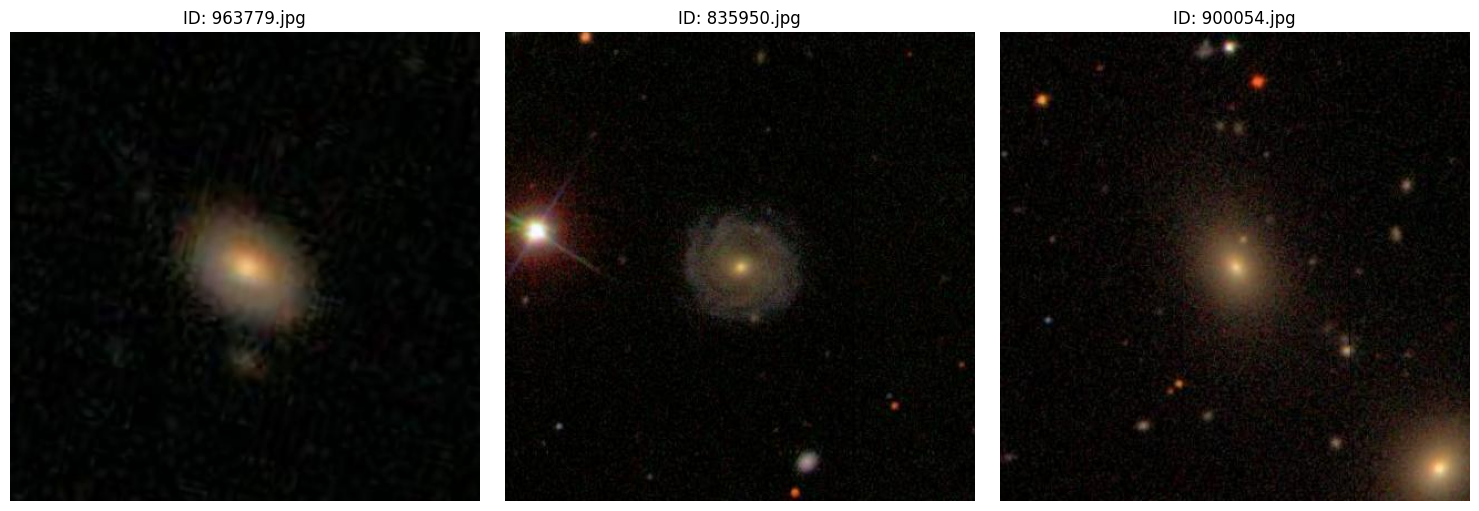

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

# Define paths
image_folder = '/content/unzipped_data/images_training_rev1'
all_images = os.listdir(image_folder)

# Select 3 random images to display side-by-side
random_samples = random.sample(all_images, 3)

# Create a "figure" (the canvas) with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print(f"Dataset Size: {len(all_images)} total images")
print("-" * 40)

for i, image_file in enumerate(random_samples):
    # Load image
    img_path = os.path.join(image_folder, image_file)
    img = mpimg.imread(img_path)

    # Displaying statistics for the FIRST image only (to keep output clean)
    if i == 0:
        print(f"Image Shape: {img.shape} (Height, Width, Channels)")
        print(f"Data Type: {img.dtype}")
        print(f"Pixel Value Range: Min={img.min()}, Max={img.max()}")
        print("-" * 40)

    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {image_file}", fontsize=12)
    axes[i].axis('off') # Hiding axis numbers for a cleaner look

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the Labels
# Making sure this path matches where i unzipped the data in Step 2/3
csv_path = '/content/unzipped_data/training_solutions_rev1.csv'
df = pd.read_csv(csv_path)

# 2. PRO Engineering: Convert IDs to Filenames
# The CSV has "100008", but files are "100008.jpg". I am fixing this.
df['GalaxyID'] = df['GalaxyID'].astype(str) + ".jpg"

# 3. PRO Engineering: Filter for Existing Files only
# I define the folder again to be safe
image_folder = '/content/unzipped_data/images_training_rev1'
available_files = set(os.listdir(image_folder))

# Keeping  only rows where the image actually exists
initial_count = len(df)
df = df[df['GalaxyID'].isin(available_files)]
final_count = len(df)

print(f"Original CSV rows: {initial_count}")
print(f"Images actually found: {final_count}")

# 4. Defining the 37 Target Columns (The outputs we want to predict)
columns = df.columns.tolist()
target_columns = columns[1:] # Skip 'GalaxyID'

# 5. Scientific Split: Train (80%) vs Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("-" * 40)
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print("-" * 40)

Original CSV rows: 61578
Images actually found: 61578
----------------------------------------
Training Samples: 49262
Validation Samples: 12316
----------------------------------------


In [ ]:
import cv2
import numpy as np

def astronomical_preprocessing(image):
    """
    Custom preprocessing for Galaxy Zoo images.
    1. Denoising: Removes background sensor noise.
    2. Central Focus: Mathematically focuses on the primary galaxy.
    """
    # Convert image to uint8 for OpenCV processing (0-255)
    # The generator provides images as floats, i need them as integers for cv2
    img_uint8 = np.clip(image, 0, 255).astype(np.uint8)

    # 1. APPLY DENOISING (Non-Local Means)
    # This removes the graininess without losing the spiral arm edges.
    denoised = cv2.fastNlMeansDenoisingColored(img_uint8, None, 10, 10, 7, 21)

    # 2. Return the image as a float32 for the Neural Network
    return denoised.astype(np.float32)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Generator (Normalize pixels)
datagen = ImageDataGenerator(rescale=1./255)

# 2. Setup the "Flow"
BATCH_SIZE = 32
TARGET_SIZE = (224, 224) # Required for VGG16

print("Setting up Training Generator...")
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',        # 'raw' because i am predicting probabilities
    shuffle=True             # Shuffle training data
)

print("\nSetting up Validation Generator...")
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False            # Never shuffle validation data
)

Setting up Training Generator...
Found 49262 validated image filenames.

Setting up Validation Generator...
Found 12316 validated image filenames.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Optional: your custom preprocessing function
def astronomical_preprocessing(img):
    # Apply denoising or filters here
    return img

# 1. Defining the Generator with Denoising and Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=astronomical_preprocessing,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True
)

# 2. Setting up the Flow
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

print("Setting up Denoised Training Generator...")

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,      # must match number of classes
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',          # because labels are multi-output numeric columns
    shuffle=True
)

Setting up Denoised Training Generator...
Found 49262 validated image filenames.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

# 1. Download the VGG16 Base Model
# weights='imagenet': Use the pre-learned knowledge
# include_top=False: Cutting off the original "cat/dog" classifier head
print("Downloading VGG16 base model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the Base Model
# I don't want to ruin the pre-learned weights, so I make them non-trainable.
base_model.trainable = False

# 3. Add the New "Galaxy" Head
x = base_model.output
x = GlobalAveragePooling2D()(x)                   # Compress the data
x = Dense(1024, activation='relu')(x)             # "Thinking" layer
predictions = Dense(37, activation='sigmoid')(x)  # Output: 37 probabilities

# 4. Combine into the Final Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the Model
# I used 'binary_crossentropy' because I am predicting multiple probabilities (0 to 1).
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Shows the structure
print("\nModel Architecture Constructed:")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Model Architecture Constructed:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        37,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,277,925 (58.28 MB)

 Trainable params: 563,237 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Starting VGG16 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.5888 - loss: 0.2979
Epoch 1: val_loss improved from None to 0.28106, saving model to vgg16_100_epochs_best.keras

Epoch 1: finished saving model to vgg16_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 850s 542ms/step - accuracy: 0.6000 - loss: 0.2868 - val_accuracy: 0.6030 - val_loss: 0.2811
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.6213 - loss: 0.2752
Epoch 2: val_loss improved from 0.28106 to 0.27335, saving model to vgg16_100_epochs_best.keras

Epoch 2: finished saving model to vgg16_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 820s 533ms/step - accuracy: 0.6230 - loss: 0.2740 - val_accuracy: 0.6263 - val_loss: 0.2734
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6348 - loss: 0.2713
Epoch 3: val_loss did not improve from 0.27335
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 835s 542ms/step - accuracy: 0.6338 - loss: 0.270

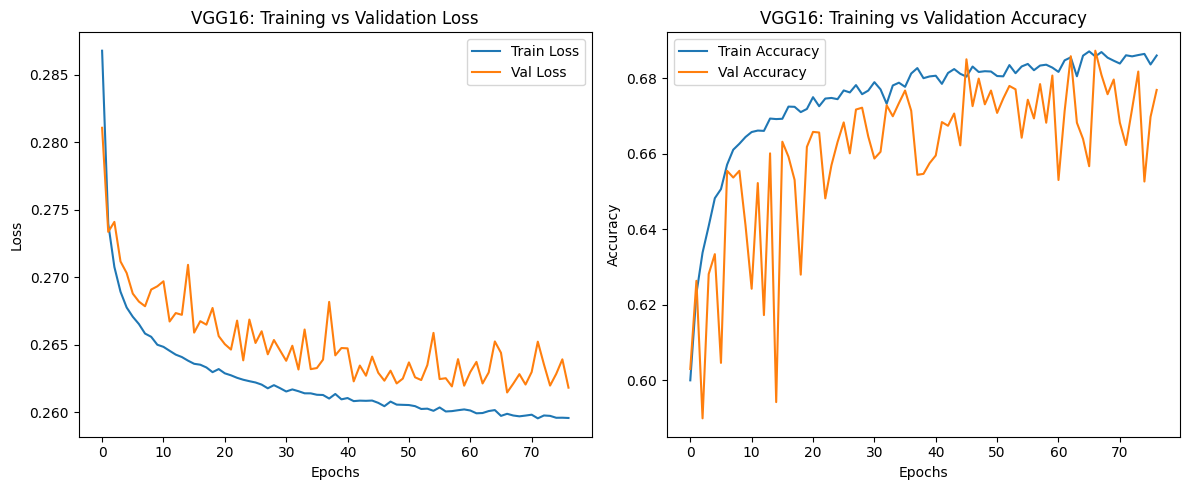

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. Setup Callbacks
checkpoint_vgg = 'vgg16_100_epochs_best.keras'
callbacks_vgg = [
    ModelCheckpoint(checkpoint_vgg, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting VGG16 Training (100 Epochs)...")
vgg_history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_vgg
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Building ResNet50 model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Starting ResNet50 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.5920 - loss: 0.3058
Epoch 1: val_loss improved from None to 0.29873, saving model to resnet50_100_epochs_best.keras

Epoch 1: finished saving model to resnet50_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 755s 481ms/step - accuracy: 0.5962 - loss: 0.3005 - val_accuracy: 0.5939 - val_loss: 0.2987
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.5987 - loss: 0.2975
Epoch 2: val_loss improved from 0.29873 to 0.29574, saving model to resnet50_100_epochs_best.keras

Epoch 2: finished saving model to resnet50_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 731s 474ms/step - accuracy: 0.5959 - loss: 0.2967 - val_accuracy: 0.5940 - val_loss: 0.2957
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.5953 - loss: 0.2955
Epoch 3: val_loss improved from 0

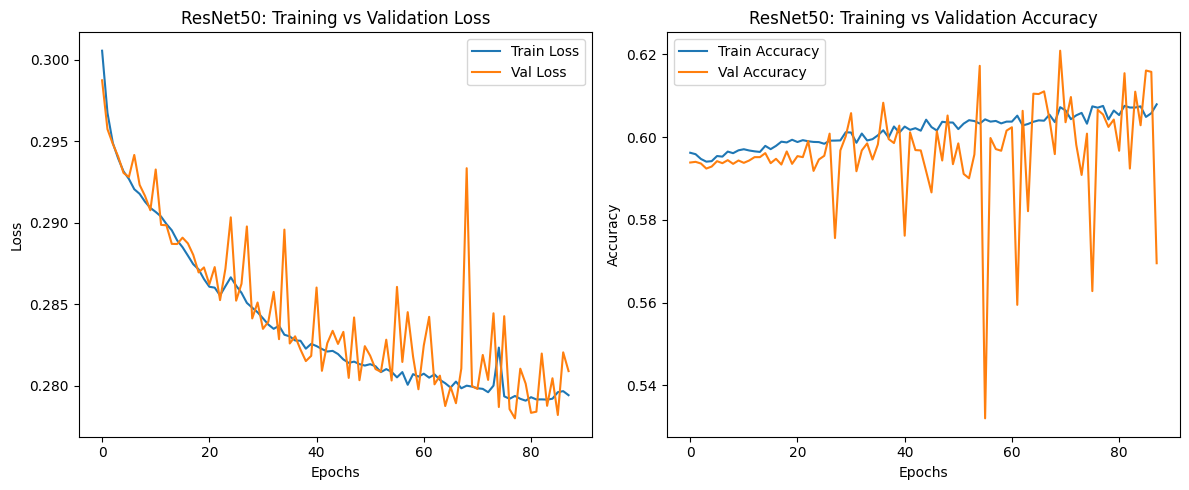

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building ResNet50 model
print("Building ResNet50 model...")
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
resnet_preds = Dense(37, activation='sigmoid')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=resnet_preds)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_resnet = 'resnet50_100_epochs_best.keras'
callbacks_resnet = [
    ModelCheckpoint(checkpoint_resnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting ResNet50 Training (100 Epochs)...")
resnet_history = resnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_resnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Building EfficientNetB0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting EfficientNetB0 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5888 - loss: 0.3059
Epoch 1: val_loss improved from None to 0.30077, saving model to efficientnetb0_100_epochs_best.keras

Epoch 1: finished saving model to efficientnetb0_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 701s 437ms/step - accuracy: 0.5957 - loss: 0.3011 - val_accuracy: 0.5939 - val_loss: 0.3008
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.5964 - loss: 0.2997
Epoch 2: val_loss improved from 0.30077 to 0.30061, saving model to efficientnetb0_100_epochs_best.keras

Epoch 2: finished saving model to efficientnetb0_100_epochs_best.keras
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 634s 412ms/step - accuracy: 0.5966 - loss: 0.2997 - val_accuracy: 0.5939 - val_loss: 0.3006
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.5991 - loss: 0.29

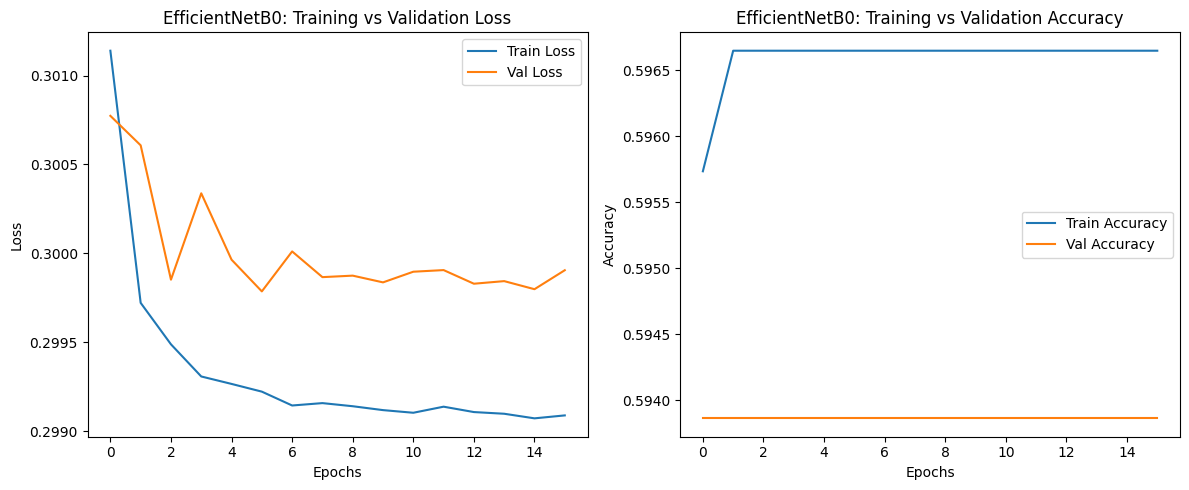

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building EfficientNetB0 model
print("Building EfficientNetB0 model...")
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
efficientnet_base.trainable = False

x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
efficientnet_preds = Dense(37, activation='sigmoid')(x)

efficientnet_model = Model(inputs=efficientnet_base.input, outputs=efficientnet_preds)
efficientnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_efficientnet = 'efficientnetb0_100_epochs_best.keras'
callbacks_efficientnet = [
    ModelCheckpoint(checkpoint_efficientnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting EfficientNetB0 Training (100 Epochs)...")
efficientnet_history = efficientnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_efficientnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(efficientnet_history.history['loss'], label='Train Loss')
plt.plot(efficientnet_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(efficientnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficientnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

print("Loading best trained models...")
vgg_model = load_model('/content/vgg16_100_epochs_best.keras')
resnet50_model = load_model('/content/resnet50_100_epochs_best.keras')
efficientnetb0_model = load_model('/content/efficientnetb0_100_epochs_best.keras')
print("All models loaded successfully!")

Loading best trained models...
All models loaded successfully!


In [ ]:
import numpy as np

print("Generating predictions for validation data...")
# Extract true labels directly from the generator
y_true = []
val_generator.reset()
for i in range(len(val_generator)):
    _, batch_y = val_generator[i]
    y_true.extend(batch_y)
y_true = np.array(y_true)

# Getting predicted values from all models
y_pred_vgg = vgg_model.predict(val_generator, verbose=1)
y_pred_resnet = resnet50_model.predict(val_generator, verbose=1)
y_pred_effnet = efficientnetb0_model.predict(val_generator, verbose=1)

Generating predictions for validation data...
385/385 ━━━━━━━━━━━━━━━━━━━━ 103s 228ms/step
385/385 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step
385/385 ━━━━━━━━━━━━━━━━━━━━ 56s 107ms/step


In [ ]:
from sklearn.metrics import mean_squared_error

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_vgg = calculate_rmse(y_true, y_pred_vgg)
rmse_resnet = calculate_rmse(y_true, y_pred_resnet)
rmse_effnet = calculate_rmse(y_true, y_pred_effnet)

print(f"VGG16 Validation RMSE          : {rmse_vgg:.4f}")
print(f"ResNet50 Validation RMSE       : {rmse_resnet:.4f}")
print(f"EfficientNetB0 Validation RMSE : {rmse_effnet:.4f}")

VGG16 Validation RMSE          : 0.1269
ResNet50 Validation RMSE       : 0.1447
EfficientNetB0 Validation RMSE : 0.1642


In [ ]:
def map_to_morphology(prob_matrix):
    """
    Maps raw 37-column Galaxy Zoo probabilities to 3 distinct morphological classes:
    0: Elliptical, 1: Spiral, 2: Irregular/Other
    """
    classes = []
    for row in prob_matrix:
        # Class 1.1: Smooth Galaxy vs Class 1.2: Features/Disk
        if row[0] > row[1] and row[0] > 0.46:
            classes.append(0) # Elliptical
        elif row[1] > row[0] and row[3] > 0.4:
            classes.append(1) # Spiral
        else:
            classes.append(2) # Irregular / Unclassified
    return np.array(classes)

# Convert continuous targets/predictions to explicit category classes
categorical_true = map_to_morphology(y_true)
categorical_vgg = map_to_morphology(y_pred_vgg)
categorical_resnet = map_to_morphology(y_pred_resnet)
categorical_effnet = map_to_morphology(y_pred_effnet)

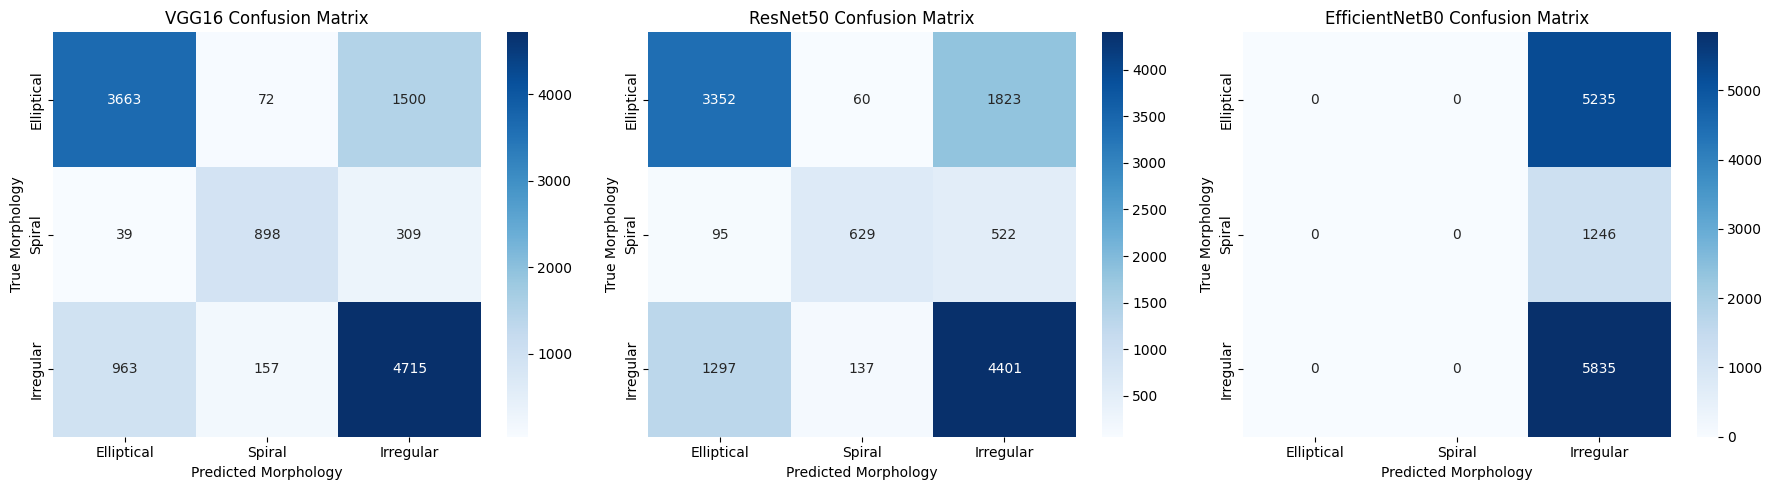

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = ['Elliptical', 'Spiral', 'Irregular']
models_preds = [categorical_vgg, categorical_resnet, categorical_effnet]
model_titles = ['VGG16', 'ResNet50', 'EfficientNetB0']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, pred in enumerate(models_preds):
    cm = confusion_matrix(categorical_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f'{model_titles[idx]} Confusion Matrix')
    axes[idx].set_ylabel('True Morphology')
    axes[idx].set_xlabel('Predicted Morphology')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Define model data collections
models_categorical_preds = {
    "VGG16": categorical_vgg,
    "ResNet50": categorical_resnet,
    "EfficientNetB0": categorical_effnet
}
class_names = ['Elliptical', 'Spiral', 'Irregular']

print("=======================================================")
print("          COMPREHENSIVE CLASSIFICATION METRICS         ")
print("=======================================================\n")

# Dictionary to hold summarized metrics for the final table
summary_data = []

for model_name, y_pred in models_categorical_preds.items():
    print(f"  --- {model_name} Classification Performance ---")

    # Calculating global accuracy
    acc = accuracy_score(categorical_true, y_pred)

    # Generating full report (Precision, Recall, F1-score per class)
    report_dict = classification_report(categorical_true, y_pred, target_names=class_names, output_dict=True)
    print(classification_report(categorical_true, y_pred, target_names=class_names))

    # Extracting macro averages to store in our summary table
    summary_data.append({
        "Model": model_name,
        "Accuracy": f"{acc * 100:.2f}%",
        "Macro Precision": f"{report_dict['macro avg']['precision']:.4f}",
        "Macro Recall": f"{report_dict['macro avg']['recall']:.4f}",
        "Macro F1-Score": f"{report_dict['macro avg']['f1-score']:.4f}"
    })
    print("-" * 55 + "\n")

# Creating and displaying a clean summary comparison DataFrame
print("=======================================================")
print("         FINAL COMPARATIVE ANALYSIS SUMMARY             ")
print("=======================================================")
summary_df = pd.DataFrame(summary_data)
display(summary_df)

          COMPREHENSIVE CLASSIFICATION METRICS         

  --- VGG16 Classification Performance ---
              precision    recall  f1-score   support

  Elliptical       0.79      0.70      0.74      5235
      Spiral       0.80      0.72      0.76      1246
   Irregular       0.72      0.81      0.76      5835

    accuracy                           0.75     12316
   macro avg       0.77      0.74      0.75     12316
weighted avg       0.76      0.75      0.75     12316

-------------------------------------------------------

  --- ResNet50 Classification Performance ---
              precision    recall  f1-score   support

  Elliptical       0.71      0.64      0.67      5235
      Spiral       0.76      0.50      0.61      1246
   Irregular       0.65      0.75      0.70      5835

    accuracy                           0.68     12316
   macro avg       0.71      0.63      0.66     12316
weighted avg       0.69      0.68      0.68     12316

-----------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,VGG16,75.32%,0.7682,0.7428,0.7533
1,ResNet50,68.06%,0.7068,0.6331,0.6595
2,EfficientNetB0,47.38%,0.1579,0.3333,0.2143


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np

# 1. Gathering all correct/incorrect prediction masks
models_masks = {
    "VGG16": (categorical_vgg == categorical_true).astype(int),
    "ResNet50": (categorical_resnet == categorical_true).astype(int),
    "EfficientNetB0": (categorical_effnet == categorical_true).astype(int)
}

model_names = list(models_masks.keys())
p_matrix = np.zeros((3, 3))

# 2. Computing pairwise McNemar tests
for i in range(3):
    for j in range(3):
        if i == j:
            p_matrix[i, j] = 1.0  # Comparing a model to itself
        else:
            mask_A = models_masks[model_names[i]]
            mask_B = models_masks[model_names[j]]

            # Building contingency elements
            a = np.sum((mask_A == 1) & (mask_B == 1))
            b = np.sum((mask_A == 1) & (mask_B == 0))
            c = np.sum((mask_A == 0) & (mask_B == 1))
            d = np.sum((mask_A == 0) & (mask_B == 0))

            # Running test with continuity correction
            res = mcnemar([[a, b], [c, d]], exact=False, correction=True)
            p_matrix[i, j] = res.pvalue

# 3. Formatting into summary table
statistical_summary_df = pd.DataFrame(
    p_matrix,
    index=model_names,
    columns=model_names
)

print("=======================================================")
print("     PAIRWISE MCNEMAR TEST P-VALUE MATRIX              ")
print("=======================================================")
display(statistical_summary_df.style.format("{:.2e}"))

     PAIRWISE MCNEMAR TEST P-VALUE MATRIX              


,VGG16,ResNet50,EfficientNetB0
VGG16,1.00e+00,1.38e-58,0.00e+00
ResNet50,1.38e-58,1.00e+00,2.65e-262
EfficientNetB0,0.00e+00,2.65e-262,1.00e+00


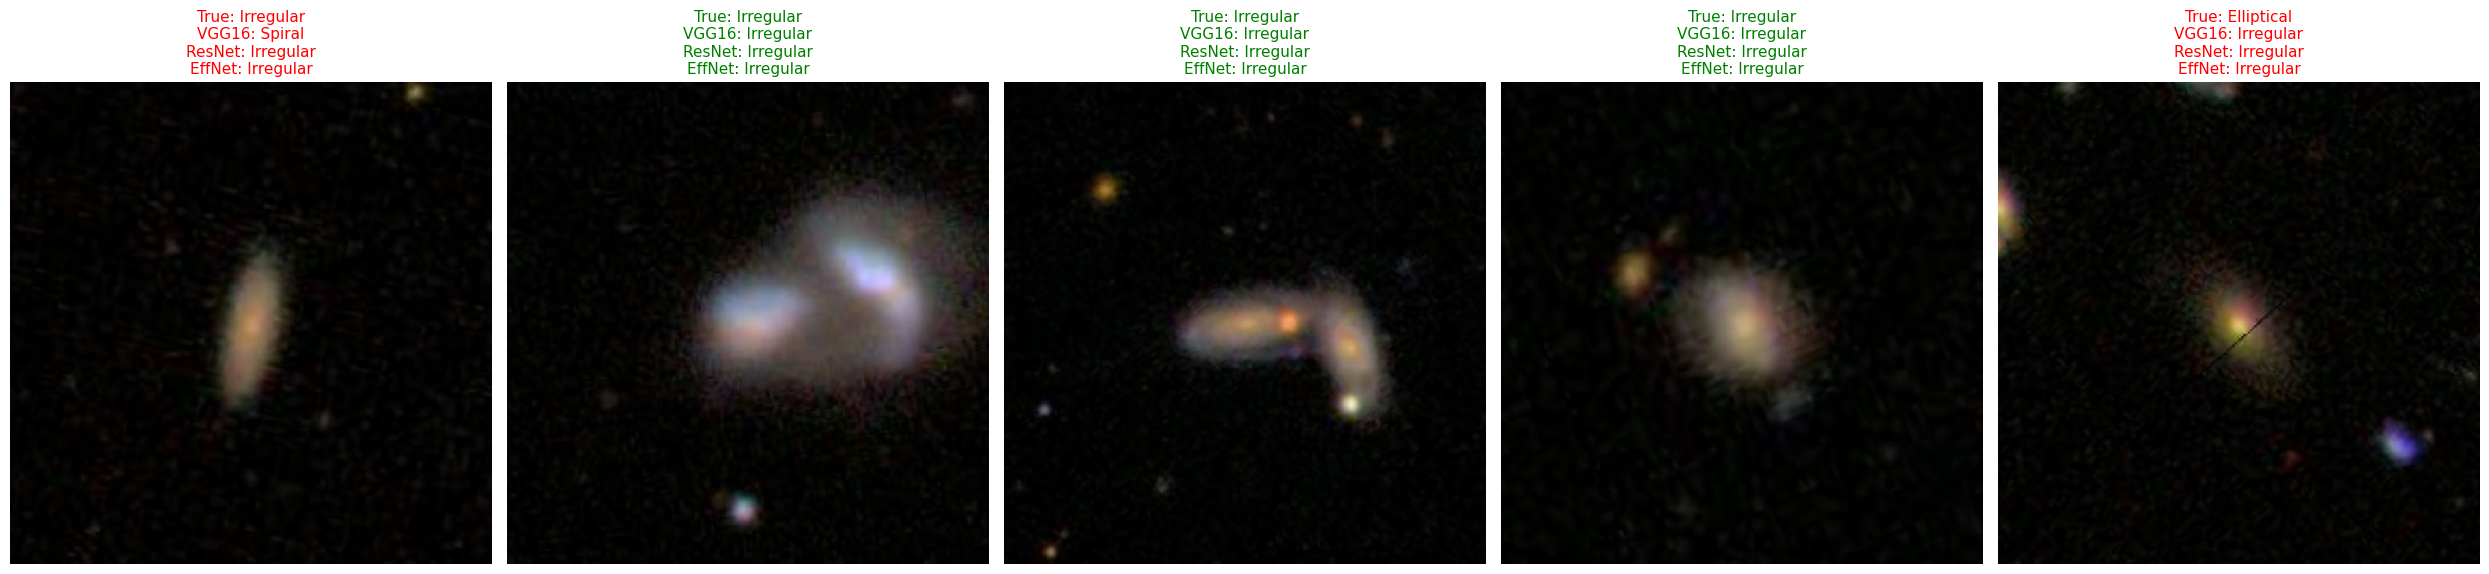

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. Reset generator and pick a few random indices from validation data
val_generator.reset()
class_names = ['Elliptical', 'Spiral', 'Irregular']

# Get a single batch of images and true labels
x_batch, y_batch = next(val_generator)

# Map continuous batch labels to categories
true_batch_categories = map_to_morphology(y_batch)

# Predict on this batch using all three models
pred_vgg_batch = map_to_morphology(vgg_model.predict_on_batch(x_batch))
pred_resnet_batch = map_to_morphology(resnet50_model.predict_on_batch(x_batch))
pred_effnet_batch = map_to_morphology(efficientnetb0_model.predict_on_batch(x_batch))

# 2. Plot 5 random galaxies with their predictions (Updated subplot dimension and size)
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
random_indices = random.sample(range(len(x_batch)), 5)

for i, idx in enumerate(random_indices):
    # Display galaxy image (rescale back to 0-255 if it was normalized by 1./255)
    img = x_batch[idx]
    if img.max() <= 1.0:
        img = (img * 255).astype('uint8')

    axes[i].imshow(img)
    axes[i].axis('off')

    # Build text label string
    title_text = (
        f"True: {class_names[true_batch_categories[idx]]}\n"
        f"VGG16: {class_names[pred_vgg_batch[idx]]}\n"
        f"ResNet: {class_names[pred_resnet_batch[idx]]}\n"
        f"EffNet: {class_names[pred_effnet_batch[idx]]}"
    )

    # Color code title depending on whether the best model (VGG16) got it right
    is_correct = true_batch_categories[idx] == pred_vgg_batch[idx]
    axes[i].set_title(title_text, fontsize=11, color='green' if is_correct else 'red')

plt.tight_layout()
plt.show()